                                   LINEAR REGRESSION-Project

Project Title: Predict New York City Airbnb Prices

Step 1: Exploratory Data Analysis (EDA) & Data Auditing

In [105]:
import kagglehub
from kagglehub import KaggleDatasetAdapter
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
df = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "dgomonov/new-york-city-airbnb-open-data",
  "AB_NYC_2019.csv",
)
df.head()

/tmp/ipykernel_4068/2428007690.py:7: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(


Using Colab cache for faster access to the 'new-york-city-airbnb-open-data' dataset.


,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0


In [106]:
df.shape

(48895, 16)

In [107]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              48895 non-null  int64  
 1   name                            48879 non-null  object 
 2   host_id                         48895 non-null  int64  
 3   host_name                       48874 non-null  object 
 4   neighbourhood_group             48895 non-null  object 
 5   neighbourhood                   48895 non-null  object 
 6   latitude                        48895 non-null  float64
 7   longitude                       48895 non-null  float64
 8   room_type                       48895 non-null  object 
 9   price                           48895 non-null  int64  
 10  minimum_nights                  48895 non-null  int64  
 11  number_of_reviews               48895 non-null  int64  
 12  last_review                     

In [108]:
df.duplicated().sum()
np.int64(0)

np.int64(0)

In [109]:
df.columns

Index(['id', 'name', 'host_id', 'host_name', 'neighbourhood_group',
       'neighbourhood', 'latitude', 'longitude', 'room_type', 'price',
       'minimum_nights', 'number_of_reviews', 'last_review',
       'reviews_per_month', 'calculated_host_listings_count',
       'availability_365'],
      dtype='object')

In [110]:
df.dtypes

,0
id,int64
name,object
host_id,int64
host_name,object
neighbourhood_group,object
neighbourhood,object
latitude,float64
longitude,float64
room_type,object
price,int64


In [111]:
numerical_columns=df.select_dtypes(include=['int64','float64']).columns
numerical_columns

Index(['id', 'host_id', 'latitude', 'longitude', 'price', 'minimum_nights',
       'number_of_reviews', 'reviews_per_month',
       'calculated_host_listings_count', 'availability_365'],
      dtype='object')

In [112]:
df.nunique()

,0
id,48895
name,47905
host_id,37457
host_name,11452
neighbourhood_group,5
neighbourhood,221
latitude,19048
longitude,14718
room_type,3
price,674


In [113]:
df.isnull().sum()

,0
id,0
name,16
host_id,0
host_name,21
neighbourhood_group,0
neighbourhood,0
latitude,0
longitude,0
room_type,0
price,0


In [114]:
df.isnull().sum()[df.isnull().sum()>0]

,0
name,16
host_name,21
last_review,10052
reviews_per_month,10052


In [115]:
missing_percentage=(df.isnull().sum()/len(df))*100
print(missing_percentage)

id                                 0.000000
name                               0.032723
host_id                            0.000000
host_name                          0.042949
neighbourhood_group                0.000000
neighbourhood                      0.000000
latitude                           0.000000
longitude                          0.000000
room_type                          0.000000
price                              0.000000
minimum_nights                     0.000000
number_of_reviews                  0.000000
last_review                       20.558339
reviews_per_month                 20.558339
calculated_host_listings_count     0.000000
availability_365                   0.000000
dtype: float64


Step 2: Data Cleaning & Handling Missing Values

In [116]:
print(df['last_review'].isnull().sum())

10052


In [117]:
df["last_review"] = pd.to_datetime(df["last_review"])
df["review_year"] = df["last_review"].dt.year
df["review_month"] = df["last_review"].dt.month
df["review_year"] = df["review_year"].fillna(0).astype(int)
df["review_month"] = df["review_month"].fillna(0).astype(int)

df.drop("last_review",axis=1, inplace=True,errors='ignore')

In [118]:
df["reviews_per_month"].isnull().sum()

np.int64(10052)

In [119]:
df[df["reviews_per_month"].isnull()]["number_of_reviews"].value_counts()

,count
number_of_reviews,
0,10052


In [120]:
df["reviews_per_month"] = pd.to_numeric(df["reviews_per_month"], errors='coerce').fillna(0)

In [121]:
df["reviews_per_month"].isnull().sum()

np.int64(0)

In [122]:
df["availability_ratio"] = df["availability_365"] / 365

In [123]:
df.drop(columns=['id','name','host_id','host_name'],inplace=True,errors='ignore')
df.columns

Index(['neighbourhood_group', 'neighbourhood', 'latitude', 'longitude',
       'room_type', 'price', 'minimum_nights', 'number_of_reviews',
       'reviews_per_month', 'calculated_host_listings_count',
       'availability_365', 'review_year', 'review_month',
       'availability_ratio'],
      dtype='object')

Step 3: Outlier Identification &Treatment

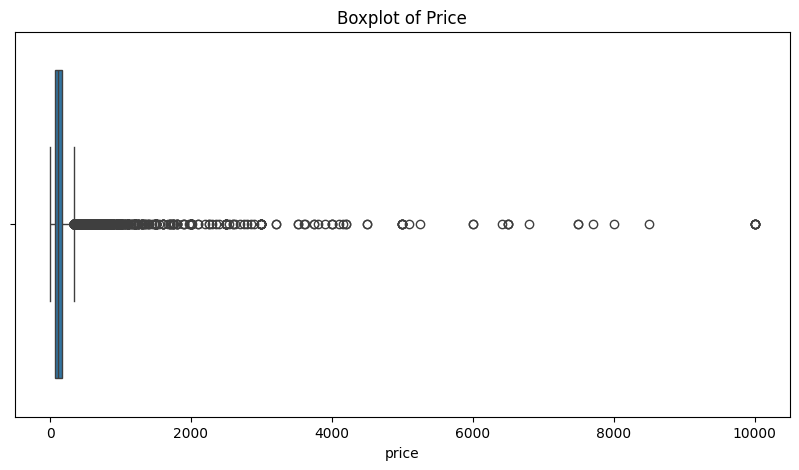

In [124]:
plt.figure(figsize=(10,5))
sns.boxplot(x=df['price'])
plt.title("Boxplot of Price")
plt.show()

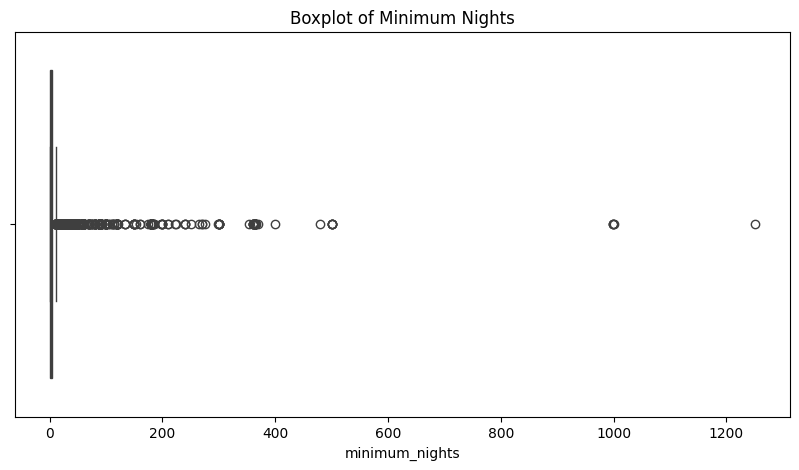

In [125]:
plt.figure(figsize=(10,5))
sns.boxplot(x=df['minimum_nights'])
plt.title("Boxplot of Minimum Nights")
plt.show()

In [126]:
Q1 = df["price"].quantile(0.25)
Q3 = df["price"].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df = df[(df["price"] >= lower) &
        (df["price"] <= upper)]
Q1 = df["minimum_nights"].quantile(0.25)
Q3 = df["minimum_nights"].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df = df[(df["minimum_nights"] >= lower) &
        (df["minimum_nights"] <= upper)]

In [127]:
print(df.columns.tolist())

['neighbourhood_group', 'neighbourhood', 'latitude', 'longitude', 'room_type', 'price', 'minimum_nights', 'number_of_reviews', 'reviews_per_month', 'calculated_host_listings_count', 'availability_365', 'review_year', 'review_month', 'availability_ratio']


Step 4: Feature Selection & Categorical Encoding

In [128]:
df.drop(columns=["neighbourhood"], inplace=True,errors='ignore')
cols_to_onehot = ["neighbourhood_group", "room_type"]
existing_cols_to_onehot = [col for col in cols_to_onehot if col in df.columns]

if existing_cols_to_onehot:
    df = pd.get_dummies(
        df,
        columns=existing_cols_to_onehot,
        drop_first=True
    )

df.head()

,latitude,longitude,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365,review_year,review_month,availability_ratio,neighbourhood_group_Brooklyn,neighbourhood_group_Manhattan,neighbourhood_group_Queens,neighbourhood_group_Staten Island,room_type_Private room,room_type_Shared room
0,40.64749,-73.97237,149,1,9,0.21,6,365,2018,10,1.000000,True,False,False,False,True,False
1,40.75362,-73.98377,225,1,45,0.38,2,355,2019,5,0.972603,False,True,False,False,False,False
2,40.80902,-73.94190,150,3,0,0.00,1,365,0,0,1.000000,False,True,False,False,True,False
3,40.68514,-73.95976,89,1,270,4.64,1,194,2019,7,0.531507,True,False,False,False,False,False
4,40.79851,-73.94399,80,10,9,0.10,1,0,2018,11,0.000000,False,True,False,False,False,False


Step 5: Feature-Target Separation & Validation Split

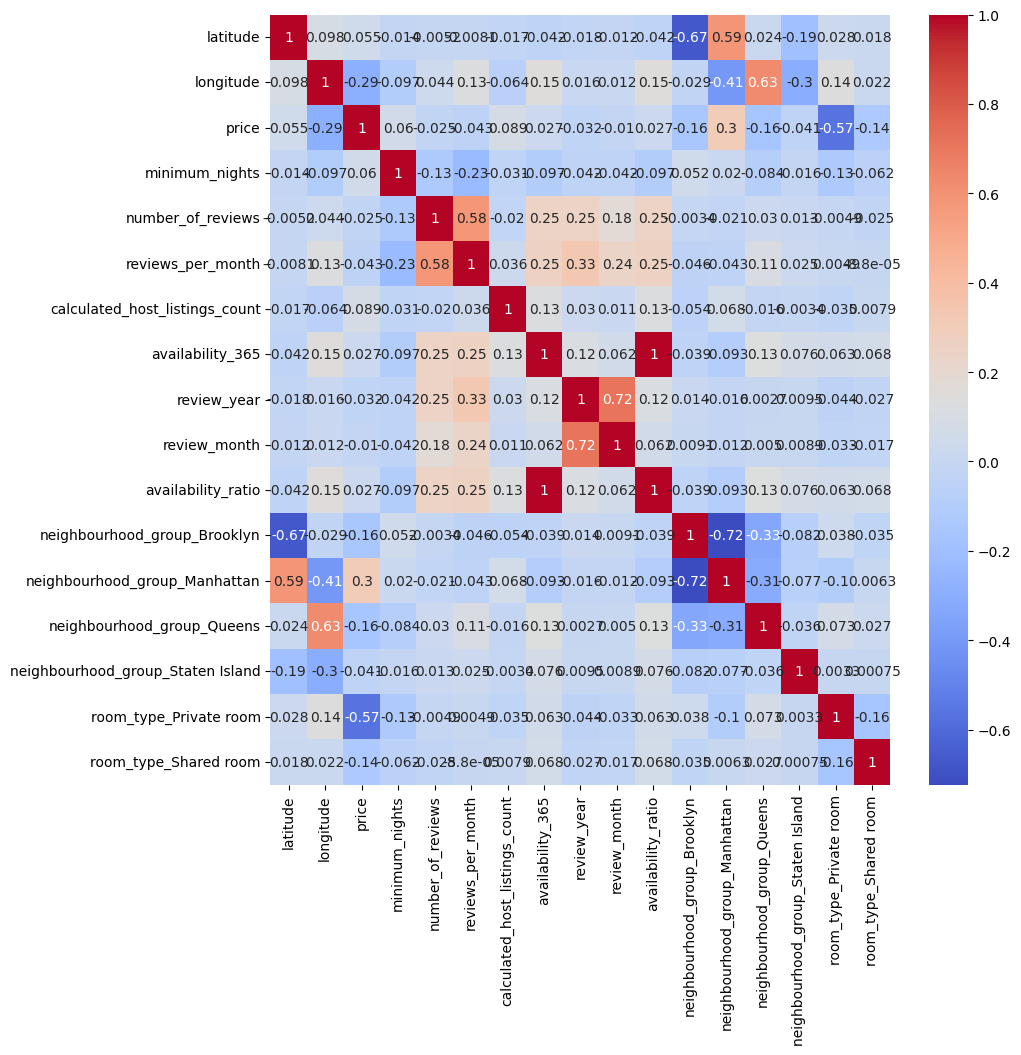

In [129]:
corr=df.corr(numeric_only=True)
plt.figure(figsize=(10,10))
sns.heatmap(corr,annot=True,cmap='coolwarm')
plt.show()

In [130]:
X=df.drop(columns=['price'])
y=np.log1p(df['price'])

In [131]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)
print("X_train: ",X_train.shape)
print("X_test: ",X_test.shape)
print("y_train: ",y_train.shape)
print("y_test: ",y_test.shape)


X_train:  (31790, 16)
X_test:  (7948, 16)
y_train:  (31790,)
y_test:  (7948,)


In [132]:
from sklearn.linear_model import LinearRegression
model=LinearRegression()
model.fit(X_train,y_train)

LinearRegression()

In [133]:
y_pred=model.predict(X_test)

In [134]:
y_pred_original = np.expm1(y_pred)

In [135]:
from sklearn.metrics import mean_squared_error,mean_absolute_error,r2_score,root_mean_squared_error
mse=mean_squared_error(y_test,y_pred)
mae=mean_absolute_error(y_test,y_pred)
rmse=np.sqrt(mse)
r2=r2_score(y_test,y_pred)
print("Mean Square Error: ",mse)
print("Mean Absolute Error: ",mae)
print("Root Mean Square Error: ",rmse)
print("R2 Score: ",r2)

Mean Square Error:  0.14694473347875708
Mean Absolute Error:  0.29498934881849576
Root Mean Square Error:  0.3833337103344253
R2 Score:  0.5428971172075241


Step 7: Residual Analysis & Interpretation

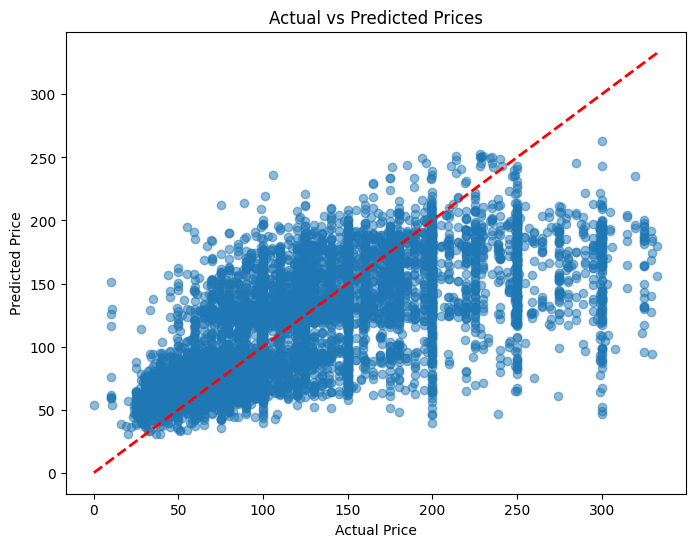

In [136]:
y_pred_original = np.expm1(y_pred)
y_test_original = np.expm1(y_test)
plt.figure(figsize=(8,6))
plt.scatter(y_test_original,
            y_pred_original,
            alpha=0.5)
plt.plot(
    [y_test_original.min(), y_test_original.max()],
    [y_test_original.min(), y_test_original.max()],
    color="red",
    linestyle="--",
    linewidth=2
)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Prices")

plt.show()

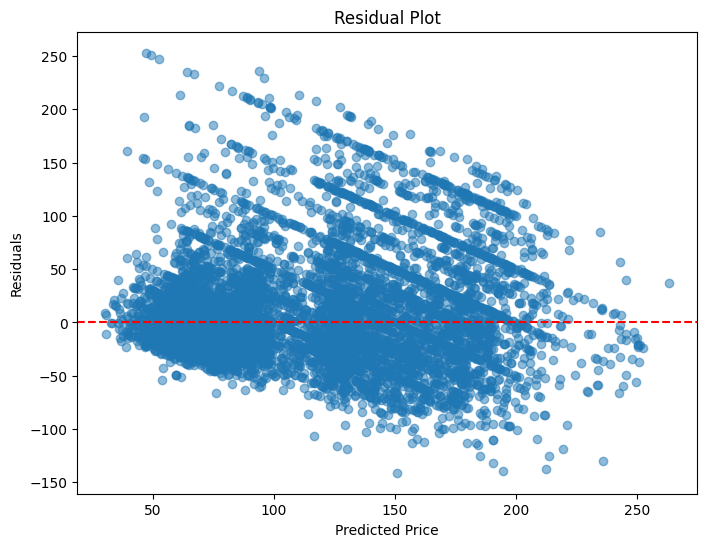

In [137]:
residuals = y_test_original - y_pred_original
plt.figure(figsize=(8,6))
plt.scatter(
    y_pred_original,
    residuals,
    alpha=0.5
)
plt.axhline(
    y=0,
    color="red",
    linestyle="--"
)
plt.xlabel("Predicted Price")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()

Task 7.3

Question: Does the model perform better on cheap listings or expensive listings, and why?

Answer

The model performs better on cheaper listings than on expensive listings.

Evidence from the Actual vs Predicted plot
For lower-priced listings (approximately ₹30–100), many points lie relatively close to the red 45° reference line. This indicates that the predicted prices are close to the actual prices, resulting in smaller prediction errors.
For higher-priced listings (above approximately ₹180–200), the points are much more scattered and are often below the red line. This means the model frequently underestimates the prices of expensive listings.